In [17]:
!pip install yfinance

import yfinance as yf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [22]:
data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")

prices = data['Close'].values

print("Data size:", len(prices))
prices[:5]

/tmp/ipykernel_1636/67143494.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Data size: 756


array([[72.40050507],
       [71.69661713],
       [72.26794434],
       [71.92804718],
       [73.08511353]])

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
prices = scaler.fit_transform(prices.reshape(-1,1))

In [32]:
seq_len = 20

X,Y = [],[]

for i in range(len(prices)-seq_len):
    X.append(prices[i:i+seq_len])
    Y.append(prices[i+seq_len])

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

print(X.shape)

torch.Size([736, 20, 1])


In [33]:
split = int(0.8*len(X))


X_train = X[:split]
Y_train = Y[:split]

X_test = X[split:]
Y_test = Y[split:]

In [34]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1,64,2,batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self,x):
        out,_ = self.lstm(x)
        return self.fc(out[:,-1])

In [35]:
model = LSTMModel()
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(),0.0005)

for epoch in range(30):
    opt.zero_grad()
    out = model(X_train)
    loss = loss_fn(out,Y_train)
    loss.backward()
    opt.step()

    print("Epoch",epoch+1,"Loss:",loss.item())

Epoch 1 Loss: 0.22250047326087952
Epoch 2 Loss: 0.21099527180194855
Epoch 3 Loss: 0.19963820278644562
Epoch 4 Loss: 0.18840517103672028
Epoch 5 Loss: 0.17729125916957855
Epoch 6 Loss: 0.1662922203540802
Epoch 7 Loss: 0.15540285408496857
Epoch 8 Loss: 0.14461903274059296
Epoch 9 Loss: 0.13394325971603394
Epoch 10 Loss: 0.12339002639055252
Epoch 11 Loss: 0.11298972368240356
Epoch 12 Loss: 0.10279355943202972
Epoch 13 Loss: 0.09288059175014496
Epoch 14 Loss: 0.08336752653121948
Epoch 15 Loss: 0.07442086189985275
Epoch 16 Loss: 0.06627260893583298
Epoch 17 Loss: 0.05923724174499512
Epoch 18 Loss: 0.05372355505824089
Epoch 19 Loss: 0.05021842569112778
Epoch 20 Loss: 0.04918527603149414
Epoch 21 Loss: 0.05076801776885986
Epoch 22 Loss: 0.05425575003027916
Epoch 23 Loss: 0.05787036567926407
Epoch 24 Loss: 0.05979333445429802
Epoch 25 Loss: 0.05938563868403435
Epoch 26 Loss: 0.05715551972389221
Epoch 27 Loss: 0.05406338721513748
Epoch 28 Loss: 0.05097457394003868
Epoch 29 Loss: 0.0484303124248

In [36]:
with torch.no_grad():
    preds = model(X_test).numpy()

In [37]:
preds = scaler.inverse_transform(preds.reshape(-1,1))
real = scaler.inverse_transform(Y_test.numpy().reshape(-1,1))

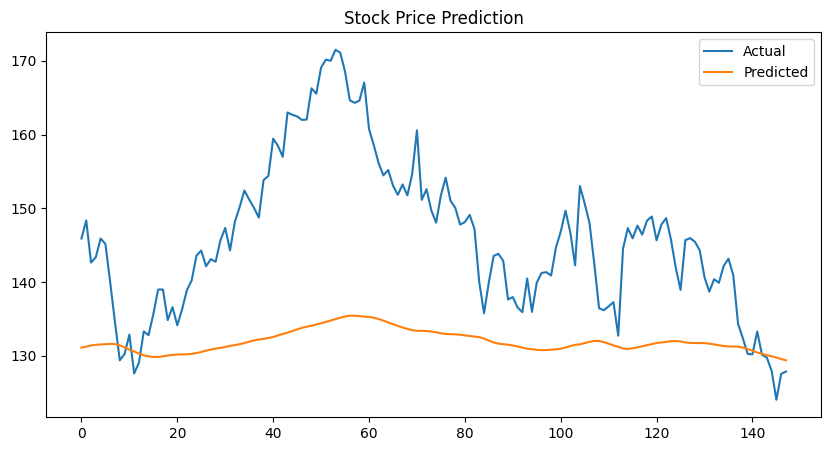

In [38]:
plt.figure(figsize=(10,5))
plt.plot(real,label="Actual")
plt.plot(preds,label="Predicted")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()